In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

def load_dataset(data_dir, img_size=(128, 128)):
    # Get class names from subdirectories
    class_names = sorted(os.listdir(data_dir))
    print(f"Found classes: {class_names}")
    
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):  # Skip non-directory files
            continue
            
        print(f"Loading {class_name}...")
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            
            try:
                # Read and preprocess image
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Warning: Could not read {img_path}")
                    continue
                    
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                img = img.astype('float32') / 255.0  # Normalize
                
                images.append(img)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")
    # Convert to numpy arrays
    images = np.array(images)
    labels = to_categorical(np.array(labels))
    
    print(f"Loaded {len(images)} images with shape {images.shape}")
    return images, labels

# Parameters
DATA_DIR = "D:\\Retina dataset for paper\\dataset"  # Update this path
VAL_SPLIT = 0.2

# Load data
X, y = load_dataset(DATA_DIR)

# Split into train/val
if len(X) > 0:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VAL_SPLIT, stratify=y)
    print(f"Train/Val split: {len(X_train)}/{len(X_val)}")
else:
    print("Error: No images were loaded!")

Found classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Loading cataract...
Loading diabetic_retinopathy...
Loading glaucoma...
Loading normal...
Loaded 10000 images with shape (10000, 128, 128, 3)
Train/Val split: 8000/2000


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

class MultiHeadAttention2D(layers.Layer):
    """Enhanced 2D attention with residual connection"""
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        
    def build(self, input_shape):
        self.attention = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.key_dim
        )
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        
    def call(self, x):
        batch_size = tf.shape(x)[0]
        h, w, c = x.shape[1], x.shape[2], x.shape[3]
        
        # Reshape and apply attention
        x_reshaped = layers.Reshape((h * w, c))(x)
        attn_output = self.attention(x_reshaped, x_reshaped)
        attn_output = layers.Reshape((h, w, c))(attn_output)
        
        # Residual connection
        return self.norm(x + attn_output)

def transformer_block(x, num_heads, key_dim, mlp_dim, dropout=0.1):
    """Enhanced transformer block with ConvMLP"""
    # Attention
    attn_output = MultiHeadAttention2D(num_heads=num_heads, key_dim=key_dim)(x)
    attn_output = layers.Dropout(dropout)(attn_output)
    
    # ConvMLP (better for spatial features)
    mlp_output = layers.Conv2D(mlp_dim, 1, activation='gelu')(attn_output)
    mlp_output = layers.Dropout(dropout)(mlp_output)
    mlp_output = layers.Conv2D(x.shape[-1], 1)(mlp_output)
    
    # Residual
    return layers.LayerNormalization(epsilon=1e-6)(attn_output + mlp_output)

def residual_block(x, filters, downsample=False):
    """Residual block for medical image features"""
    shortcut = x
    stride = 2 if downsample else 1
    
    x = layers.Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Ensure shortcut matches dimensions
    if shortcut.shape[-1] != filters:  # Channel mismatch
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
    
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

def cross_attention_fusion(cnn_features, trans_features, embed_dim):
    """Fixed fusion with proper shape handling"""
    # Project to common dimension
    cnn_proj = layers.Conv2D(embed_dim, 1)(cnn_features)
    trans_proj = layers.Conv2D(embed_dim, 1)(trans_features)
    
    # Reshape for attention
    cnn_flat = layers.Reshape((-1, embed_dim))(cnn_proj)
    trans_flat = layers.Reshape((-1, embed_dim))(trans_proj)
    
    # Cross-attention
    fused = layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim//4)(
        query=cnn_flat, value=trans_flat, key=trans_flat
    )
    
    # Fix: Convert [embed_dim] to tuple before concatenation
    target_shape = tuple(cnn_features.shape[1:-1]) + (embed_dim,)
    return layers.Reshape(target_shape)(fused)

def create_improved_hybrid_model(input_shape=(128, 128, 3), num_classes=4):
    """Final hybrid model with all improvements"""
    inputs = layers.Input(shape=input_shape)
    
    # --- Enhanced CNN Backbone ---
    x = layers.Conv2D(32, 7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)  # 32x32
    
    x = residual_block(x, 64, downsample=True)  # 16x16
    x = residual_block(x, 128, downsample=True)  # 8x8
    cnn_features = residual_block(x, 256)  # 8x8
    
    # --- Deeper Transformer Pathway ---
    trans_features = layers.Conv2D(256, 1)(cnn_features)  # Project to transformer dim
    for _ in range(4):  # 4 transformer blocks
        trans_features = transformer_block(
            trans_features, 
            num_heads=8, 
            key_dim=64, 
            mlp_dim=512
        )
    
    # --- Cross-Attention Fusion ---
    fused = cross_attention_fusion(
        cnn_features=cnn_features,
        trans_features=trans_features,
        embed_dim=256
    )
    
    # --- Classifier Head ---
    x = layers.GlobalAveragePooling2D()(fused)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    # --- Advanced Training Setup ---
    optimizer = tf.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    
    return model

# Create and verify
model = create_improved_hybrid_model()
model.summary()

# Test prediction
test_input = tf.random.normal((2, 128, 128, 3))
print("Output shape:", model.predict(test_input).shape)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 64, 64,    │      4,736 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_51[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_52[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 16, 16,    │     36,928 │ activation_21[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_53[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_54[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 16, 16,    │          0 │ add_17[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ activation_22[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,835,652 (18.45 MB)

 Trainable params: 4,833,796 (18.44 MB)

 Non-trainable params: 1,856 (7.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Output shape: (2, 4)


In [7]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,  # Increased due to deeper model
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 89s 269ms/step - accuracy: 0.5389 - loss: 1.0839 - val_accuracy: 0.2915 - val_loss: 2.4493 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 65s 260ms/step - accuracy: 0.8298 - loss: 0.6728 - val_accuracy: 0.3575 - val_loss: 2.0118 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step - accuracy: 0.8878 - loss: 0.5792 - val_accuracy: 0.7295 - val_loss: 0.8702 - learning_rate: 1.0000e-04
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 238ms/step - accuracy: 0.9031 - loss: 0.5426 - val_accuracy: 0.8665 - val_loss: 0.6400 - learning_rate: 1.0000e-04
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 238ms/step - accuracy: 0.9257 - loss: 0.5011 - val_accuracy: 0.8965 - val_loss: 0.5760 - learning_rate: 1.0000e-04
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 239ms/step - accuracy: 0.9361 - loss: 0.4810 - val_accuracy: 0.8570 - val_loss: 0.6958 - learning_rate: 1.0000e-04
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 23

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

def load_test_data(test_dir, img_size=(128, 128)):
    test_images = []
    test_labels = []
    class_names = sorted(os.listdir(test_dir)) 
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            
            # Load and resize image
            img = image.load_img(img_path, target_size=img_size)
            img_array = image.img_to_array(img)  # Convert to numpy array
            img_array = img_array / 255.0         # Normalize [0, 1]
            
            test_images.append(img_array)
            test_labels.append(class_idx)  # Assign class index (0, 1, 2...)
    
    return np.array(test_images), np.array(test_labels)

# Load test data
X_test, y_test = load_test_data("D:\\Retina dataset for paper\\test dataset", img_size=(128, 128))
print(f"Test images shape: {X_test.shape}, Test labels shape: {y_test.shape}")

Test images shape: (4000, 128, 128, 3), Test labels shape: (4000,)


In [9]:
y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes=4)  # 4 classes

In [10]:
loss, accuracy = model.evaluate(X_test, y_test_categorical)  # For categorical labels
print(f"Test Accuracy: {accuracy * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9753 - loss: 0.4016
Test Accuracy: 98.30%


In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test  # True labels (0, 1, 2, ...)

# 2. Classification report
class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  # Replace with your classes
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n", report)

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step
Classification Report:
                       precision    recall  f1-score   support

            cataract     1.0000    0.9520    0.9754      1000
diabetic_retinopathy     0.9980    1.0000    0.9990      1000
            glaucoma     0.9909    0.9820    0.9864      1000
              normal     0.9460    0.9980    0.9713      1000

            accuracy                         0.9830      4000
           macro avg     0.9837    0.9830    0.9830      4000
        weighted avg     0.9837    0.9830    0.9830      4000



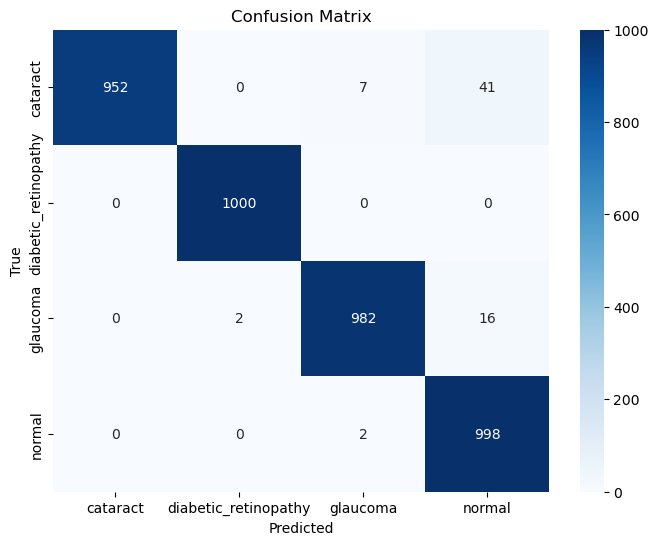

In [12]:
# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()